In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date

In [3]:
df = pd.read_csv("datasets/1_Daily_minimum_temps.csv")
df.head()

,Date,Temp
0,01/01/81,20.7
1,01/02/81,17.9
2,01/03/81,18.8
3,01/04/81,14.6
4,01/05/81,15.8


In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df['Temp'] = pd.to_numeric(df['Temp'].str.replace(r'[^0-9.\-]+', '', regex=True), errors='coerce').astype('float32')
df.head()

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_24124\2842725461.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


,Date,Temp
0,1981-01-01,20.700001
1,1981-01-02,17.900000
2,1981-01-03,18.799999
3,1981-01-04,14.600000
4,1981-01-05,15.800000


Check for NaN values

In [5]:
count = 0
for item in df['Temp']:
    if (item == 'NaN'):
        count += 1

count

0

In [6]:
df

,Date,Temp
0,1981-01-01,20.700001
1,1981-01-02,17.900000
2,1981-01-03,18.799999
3,1981-01-04,14.600000
4,1981-01-05,15.800000
...,...,...
3645,1990-12-27,14.000000
3646,1990-12-28,13.600000
3647,1990-12-29,13.500000
3648,1990-12-30,15.700000


In [ ]:
# set Date as DatetimeIndex and sort
df = df.set_index('Date').sort_index()

# ensure daily frequency
df = df.asfreq('D')

print(df.index.min(), df.index.max(), df.index.freq)
df.head()

1981-01-01 00:00:00 1990-12-31 00:00:00 <Day>


,Temp
Date,
1981-01-01,20.700001
1981-01-02,17.900000
1981-01-03,18.799999
1981-01-04,14.600000
1981-01-05,15.800000


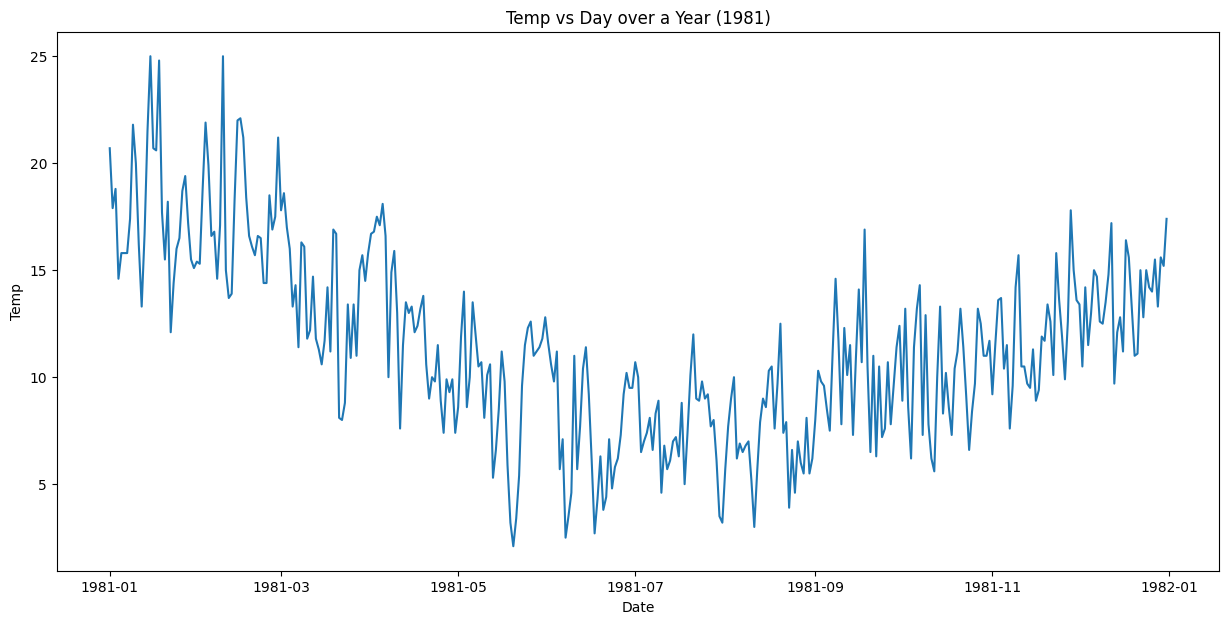

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(df.index[:365], df['Temp'][:365])
plt.title("Temp vs Day over a Year (1981)")
plt.xlabel("Date")
plt.ylabel("Temp")
plt.show()

In [13]:
df.to_csv("datasets/preprocessed_dataset.csv")
print("Dataset saved in .CSV")

Dataset saved in .CSV
